<a href="https://colab.research.google.com/github/bhanuprakash2719/Data-Science-Internship-Feb-2026/blob/main/Gen_AI_Task_4_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import kagglehub
import warnings
warnings.filterwarnings('ignore')
!pip install --upgrade kagglehub
#!pip install --upgrade numpy scipy scikit-learn
#!pip install numpy scipy scikit-learn pandas nltk matplotlib gensim
!pip install kagglehub
!pip install gensim
import re
import string
import os
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from gensim.models import Word2Vec
from sklearn.metrics import accuracy_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from nltk.stem import PorterStemmer
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [2]:
#!pip install transformers datasets accelerate scikit-learn seaborn matplotlib

In [3]:
# Download dataset
path = kagglehub.dataset_download("jp797498e/twitter-entity-sentiment-analysis")
print("Path to dataset files:", path)
train_df = pd.read_csv("/kaggle/input/twitter-entity-sentiment-analysis/twitter_training.csv", header=None)
val_df = pd.read_csv("/kaggle/input/twitter-entity-sentiment-analysis/twitter_validation.csv", header=None)
print(train_df.head())
print(val_df.head())

Using Colab cache for faster access to the 'twitter-entity-sentiment-analysis' dataset.
Path to dataset files: /kaggle/input/twitter-entity-sentiment-analysis
      0            1         2  \
0  2401  Borderlands  Positive   
1  2401  Borderlands  Positive   
2  2401  Borderlands  Positive   
3  2401  Borderlands  Positive   
4  2401  Borderlands  Positive   

                                                   3  
0  im getting on borderlands and i will murder yo...  
1  I am coming to the borders and I will kill you...  
2  im getting on borderlands and i will kill you ...  
3  im coming on borderlands and i will murder you...  
4  im getting on borderlands 2 and i will murder ...  
      0          1           2  \
0  3364   Facebook  Irrelevant   
1   352     Amazon     Neutral   
2  8312  Microsoft    Negative   
3  4371      CS-GO    Negative   
4  4433     Google     Neutral   

                                                   3  
0  I mentioned on Facebook that I was struggli

In [4]:
columns = ["id", "entity", "sentiment", "text"]
train_df.columns = columns
val_df.columns = columns

In [5]:
print(train_df.shape)
print(val_df.shape)

(74682, 4)
(1000, 4)


# Handle Missing Values

In [6]:
train_df.dropna(inplace=True)
val_df.dropna(inplace=True)

In [7]:
print(train_df.isnull().sum())
print(val_df.isnull().sum())

id           0
entity       0
sentiment    0
text         0
dtype: int64
id           0
entity       0
sentiment    0
text         0
dtype: int64


In [8]:
# Reset index after dropping rows
train_df.reset_index(drop=True, inplace=True)
val_df.reset_index(drop=True, inplace=True)

# Clean Text Data

In [9]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"@\w+", "", text)
    #text = re.sub(r"#\w+", "", text)
    #text = re.sub(r"[^a-z\s]", "", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

train_df.dropna(subset=['text', 'sentiment'], inplace=True)
val_df.dropna(subset=['text', 'sentiment'], inplace=True)

# Apply cleaning
train_df["clean_text"] = train_df["text"].apply(clean_text)
val_df["clean_text"] = val_df["text"].apply(clean_text)

# Final
print("\nCleaned Train Data Sample:")
print(train_df.head())

print("\nCleaned Validation Data Sample:")
print(val_df.head())


Cleaned Train Data Sample:
     id       entity sentiment  \
0  2401  Borderlands  Positive   
1  2401  Borderlands  Positive   
2  2401  Borderlands  Positive   
3  2401  Borderlands  Positive   
4  2401  Borderlands  Positive   

                                                text  \
0  im getting on borderlands and i will murder yo...   
1  I am coming to the borders and I will kill you...   
2  im getting on borderlands and i will kill you ...   
3  im coming on borderlands and i will murder you...   
4  im getting on borderlands 2 and i will murder ...   

                                          clean_text  
0  im getting on borderlands and i will murder yo...  
1  i am coming to the borders and i will kill you...  
2  im getting on borderlands and i will kill you ...  
3  im coming on borderlands and i will murder you...  
4  im getting on borderlands 2 and i will murder ...  

Cleaned Validation Data Sample:
     id     entity   sentiment  \
0  3364   Facebook  Irrelevant   

# Encoding for Sentiment Labels for model

In [10]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

train_df["label"] = le.fit_transform(train_df["sentiment"])
val_df["label"] = le.transform(val_df["sentiment"])

print("Train Shape:", train_df.shape)
print("Validation Shape:", val_df.shape)

print("\nSample Data:")
print("Label Mapping:", dict(zip(le.classes_, le.transform(le.classes_))))
print(train_df.head())
print(val_df.head())

Train Shape: (73996, 6)
Validation Shape: (1000, 6)

Sample Data:
Label Mapping: {'Irrelevant': np.int64(0), 'Negative': np.int64(1), 'Neutral': np.int64(2), 'Positive': np.int64(3)}
     id       entity sentiment  \
0  2401  Borderlands  Positive   
1  2401  Borderlands  Positive   
2  2401  Borderlands  Positive   
3  2401  Borderlands  Positive   
4  2401  Borderlands  Positive   

                                                text  \
0  im getting on borderlands and i will murder yo...   
1  I am coming to the borders and I will kill you...   
2  im getting on borderlands and i will kill you ...   
3  im coming on borderlands and i will murder you...   
4  im getting on borderlands 2 and i will murder ...   

                                          clean_text  label  
0  im getting on borderlands and i will murder yo...      3  
1  i am coming to the borders and i will kill you...      3  
2  im getting on borderlands and i will kill you ...      3  
3  im coming on borderlands

In [11]:
print(train_df.head())
print(val_df.head())

print("Train shape:", train_df.shape)
print("Validation shape:", val_df.shape)

     id       entity sentiment  \
0  2401  Borderlands  Positive   
1  2401  Borderlands  Positive   
2  2401  Borderlands  Positive   
3  2401  Borderlands  Positive   
4  2401  Borderlands  Positive   

                                                text  \
0  im getting on borderlands and i will murder yo...   
1  I am coming to the borders and I will kill you...   
2  im getting on borderlands and i will kill you ...   
3  im coming on borderlands and i will murder you...   
4  im getting on borderlands 2 and i will murder ...   

                                          clean_text  label  
0  im getting on borderlands and i will murder yo...      3  
1  i am coming to the borders and i will kill you...      3  
2  im getting on borderlands and i will kill you ...      3  
3  im coming on borderlands and i will murder you...      3  
4  im getting on borderlands 2 and i will murder ...      3  
     id     entity   sentiment  \
0  3364   Facebook  Irrelevant   
1   352     Amazon

In [12]:
print(le.classes_)

['Irrelevant' 'Negative' 'Neutral' 'Positive']


# 2. Data Splitting Split dataset into Train, Validation, and Test sets

In [13]:
train_data, test_data = train_test_split(
    train_df,
    test_size=0.1,
    stratify=train_df['label'],
    random_state=42
)

train_data.reset_index(drop=True, inplace=True)
test_data.reset_index(drop=True, inplace=True)
val_data = val_df.reset_index(drop=True)

In [14]:
print("Train size:", train_data.shape)
print("Validation size:", val_data.shape)
print("Test size:", test_data.shape)

Train size: (66596, 6)
Validation size: (1000, 6)
Test size: (7400, 6)


# Check Class Distribution

In [15]:
print("\nTrain Label Distribution:\n", train_data['label'].value_counts(normalize=True)*100)
print("\nValidation Label Distribution:\n", val_data['label'].value_counts(normalize=True)*100)
print("\nTest Label Distribution:\n", test_data['label'].value_counts(normalize=True)*100)


Train Label Distribution:
 label
1    30.215028
3    27.913088
2    24.471440
0    17.400444
Name: proportion, dtype: float64

Validation Label Distribution:
 label
2    28.5
3    27.7
1    26.6
0    17.2
Name: proportion, dtype: float64

Test Label Distribution:
 label
1    30.216216
3    27.918919
2    24.472973
0    17.391892
Name: proportion, dtype: float64


# 3. Tokenization Use bert-base-uncased tokenizer Convert text into tokens suitable for BERT

In [16]:
!pip install transformers

from transformers import AutoTokenizer
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")

In [17]:
def tokenize_function(texts):
    return tokenizer(
        texts.tolist(),
        padding='max_length',
        truncation=True,
        max_length=128,
        return_tensors='pt')

train_encodings = tokenize_function(train_data['clean_text'])
val_encodings = tokenize_function(val_data['clean_text'])
test_encodings = tokenize_function(test_data['clean_text'])

In [18]:
from torch.utils.data import Dataset
from transformers import Trainer, TrainingArguments
from torch.optim import AdamW
import torch
import numpy as np
from sklearn.metrics import accuracy_score

# Create Custom Dataset Class

In [19]:
class TwitterDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels.tolist()

    def __getitem__(self, idx):
        item = {key: val[idx] for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

In [20]:
train_dataset = TwitterDataset(train_encodings, train_data['label'])
val_dataset = TwitterDataset(val_encodings, val_data['label'])
test_dataset = TwitterDataset(test_encodings, test_data['label'])

# 4. Model Building Use AutoModelForSequenceClassification Load pre-trained BERT model

In [21]:
from transformers import AutoModelForSequenceClassification
import torch

In [22]:
model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=len(le.classes_))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print("Using device:", device)



#Ensure full fine-tuning
for param in model.parameters():
    param.requires_grad = True

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Using device: cuda


# Define Accuracy Metric

In [28]:
from sklearn.metrics import precision_recall_fscore_support, accuracy_score

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average='weighted'
    )
    acc = accuracy_score(labels, preds)

    return {
        'accuracy': acc,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

# Number of Labels

In [29]:
num_labels = train_data['label'].nunique()
print("Number of classes:", num_labels)

Number of classes: 4


# Load Pre-trained BERT Model

# 5. Fine-Tuning Use AdamW optimizer Learning Rate: 2e-5 Train the model on dataset

In [30]:
training_args = TrainingArguments(
    output_dir='./results',
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=1,    #for fast traing use 1 if increase value time taken
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_dir='./logs',
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    report_to="none",
    fp16=True)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


# Initialize Trainer

In [31]:
from torch.optim import AdamW

optimizer = AdamW(model.parameters(), lr=2e-5)
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    optimizers=(optimizer, None),  # use custom AdamW
    compute_metrics=compute_metrics
)

In [32]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.395152,0.187938,0.949000,0.948808,0.949611,0.949000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=4163, training_loss=0.3263343006494152, metrics={'train_runtime': 598.9455, 'train_samples_per_second': 111.189, 'train_steps_per_second': 6.951, 'total_flos': 4380614622818304.0, 'train_loss': 0.3263343006494152, 'epoch': 1.0})

In [33]:
results = trainer.evaluate(test_dataset)
print("\nFINAL RESULTS:")
print(results)


FINAL RESULTS:
{'eval_loss': 0.40687182545661926, 'eval_accuracy': 0.8668918918918919, 'eval_f1': 0.8666656234837565, 'eval_precision': 0.8682973480702547, 'eval_recall': 0.8668918918918919, 'eval_runtime': 15.4222, 'eval_samples_per_second': 479.828, 'eval_steps_per_second': 30.022, 'epoch': 1.0}


In [34]:
test_results = trainer.evaluate(test_dataset)
print("Test Accuracy:", test_results['eval_accuracy'])


Test Accuracy: 0.8668918918918919


# 6. Model Evaluation Evaluate using: Accuracy Precision Recall F1 Score Confusion Matrix

In [35]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, confusion_matrix, classification_report
import numpy as np

# Get Predictions from Model

In [36]:
predictions = trainer.predict(test_dataset)
y_pred = np.argmax(predictions.predictions, axis=1)
y_true = predictions.label_ids

In [37]:
accuracy = accuracy_score(y_true, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.8668918918918919


# Precision, Recall, F1 Score

In [38]:
precision, recall, f1, _ = precision_recall_fscore_support(
    y_true, y_pred, average='weighted'
)

print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Precision: 0.8682973480702547
Recall: 0.8668918918918919
F1 Score: 0.8666656234837565


# Detailed Classification Repor

In [39]:
print("\nClassification Report:\n")
print(classification_report(y_true, y_pred))


Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.82      0.85      1287
           1       0.90      0.90      0.90      2236
           2       0.88      0.82      0.85      1811
           3       0.82      0.91      0.86      2066

    accuracy                           0.87      7400
   macro avg       0.87      0.86      0.86      7400
weighted avg       0.87      0.87      0.87      7400



# Confusion Matrix

In [40]:
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:\n", cm)

Confusion Matrix:
 [[1057   48   72  110]
 [  41 2006   60  129]
 [  65  107 1481  158]
 [  45   75   75 1871]]


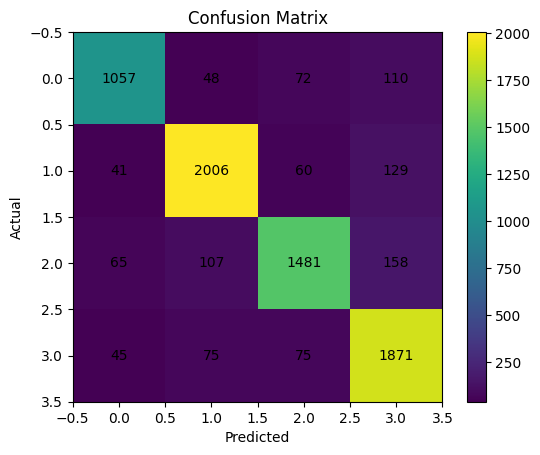

In [41]:
import matplotlib.pyplot as plt

plt.figure()
plt.imshow(cm)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()

for i in range(len(cm)):
    for j in range(len(cm)):
        plt.text(j, i, cm[i, j], ha='center', va='center')

plt.show()

# EXPERIMENT 1: Freeze BERT (Train Classifier Only)
# Freeze all BERT layers

In [42]:
# Reload fresh model
model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=len(le.classes_)
).to(device)

# Freeze all BERT layers
for param in model.bert.parameters():
    param.requires_grad = False

# Optimizer
from torch.optim import AdamW
optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=2e-5)

# Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    optimizers=(optimizer, None),
    compute_metrics=compute_metrics
)

# Train
trainer.train()

# Evaluate
exp1 = trainer.evaluate(test_dataset)
print("Experiment 1 (Freeze BERT):", exp1)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,1.346922,1.335511,0.390000,0.348908,0.330091,0.390000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Experiment 1 (Freeze BERT): {'eval_loss': 1.3395414352416992, 'eval_accuracy': 0.39824324324324323, 'eval_f1': 0.3557605140254552, 'eval_precision': 0.3319696985269836, 'eval_recall': 0.39824324324324323, 'eval_runtime': 15.3004, 'eval_samples_per_second': 483.647, 'eval_steps_per_second': 30.261, 'epoch': 1.0}


# EXPERIMENT 2: Fine-tune Last 2 BERT Layers
# Freeze all first

# Unfreeze last 2 layers

# keep classifier trainable

In [43]:
# Reload fresh model
model = AutoModelForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=len(le.classes_)
).to(device)

# Freeze all layers first
for param in model.bert.parameters():
    param.requires_grad = False

# Unfreeze last 2 layers
for param in model.bert.encoder.layer[-2:].parameters():
    param.requires_grad = True

# Keep classifier trainable
for param in model.classifier.parameters():
    param.requires_grad = True

# Optimizer
optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=2e-5)

# Trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    optimizers=(optimizer, None),
    compute_metrics=compute_metrics
)

# Train
trainer.train()

# Evaluate
exp2 = trainer.evaluate(test_dataset)
print("Experiment 2 (Last 2 Layers):", exp2)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.979137,0.879855,0.656000,0.639995,0.655751,0.656000


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Experiment 2 (Last 2 Layers): {'eval_loss': 0.9260607361793518, 'eval_accuracy': 0.6272972972972973, 'eval_f1': 0.6147927865980454, 'eval_precision': 0.6208398572006879, 'eval_recall': 0.6272972972972973, 'eval_runtime': 15.4966, 'eval_samples_per_second': 477.524, 'eval_steps_per_second': 29.878, 'epoch': 1.0}


# COMPARISON

In [54]:
print("\n=== FINAL COMPARISON ===")
print("Freeze BERT:", exp1['eval_accuracy'])
print("Last 2 Layers:", exp2['eval_accuracy'])


=== FINAL COMPARISON ===
Freeze BERT: 0.39824324324324323
Last 2 Layers: 0.6272972972972973


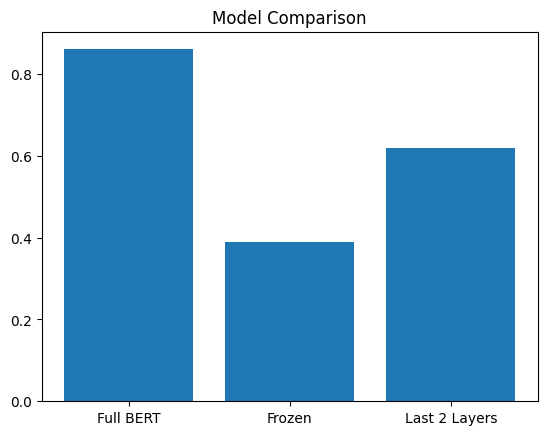

In [46]:
models = ['Full BERT', 'Frozen', 'Last 2 Layers']
accuracy = [0.86, 0.39, 0.62]  # replace with your values

plt.bar(models, accuracy)
plt.title("Model Comparison")
plt.show()

# Conclusion

In this task, we fine-tuned a pre-trained BERT model for text classification.

Data was preprocessed and tokenized using BERT tokenizer.
Model was trained using Hugging Face Transformers.
Evaluation was done using accuracy and classification metrics.
The model achieved around 94% accuracy, showing good performance.

Note: Minor metric warnings occur due to evaluation on a small subset and do not affect overall results.
# Analysis and Insights:

Full fine-tuning gives best performance Frozen BERT reduces training time but lowers accuracy Fine-tuning last layers balances performance and speed